In [53]:
import jax.numpy as jnp
import jax
from jax import Array
from scipy.linalg import ordqz
from jax.scipy.linalg import inv
import numpy as np
jax.config.update("jax_enable_x64", True)

$$\begin{bmatrix}X_{t+1}\\ _tP_{t+1}\end{bmatrix}=A\begin{bmatrix}X_{t}\\ P_{t}\end{bmatrix}+\gamma Z_t$$

$\varsigma$, $\varkappa$

In [54]:
sigma = 1
phi_y = 0.5
phi_p = 1.5
phi_w = 5
varkappa_p = 0.3
varkappa_w = 0.2
beta = 0.99
lambda_p = 0.25
lambda_w = 0.25

A_0w = jnp.array([[sigma+phi_y, phi_p, phi_w,0],
                  [-varkappa_p, 1, 0,0],
                  [-varkappa_w, 0, 1,0],
                  [0,-1,1,1]])

A_1w = jnp.array([[sigma, 1, 0,0],
                  [0, beta,0, lambda_p],
                  [0,0,beta,-lambda_w],
                  [0,0,0,1]])

B_0w = jnp.array([[1,0],
                  [0,0],
                  [0,0],
                  [0,1]])

$$AE[x_{t+1}] = B x_t + C z_t$$

In [55]:
def solve_klein(A:Array, B:Array, C:Array, k0:Array, z0:Array):
    """
    Solves the system 
    AE[x_{t+1}] = Bx_t + C z_t
    x_t is decomposed in k_t backward-looking variables and d_t forward looking variables 
    """
    S, T, _, _, Q, Z = ordqz(A, B, output='complex',sort=lambda alpha,beta: jnp.round(jnp.abs(beta/jnp.maximum(alpha,1e-15)),6)<=1) # type: ignore
    Q = Q.conjugate().T
    n_s = len([_ for i in range(S.shape[0]) if np.abs(S[i,i])>1e-6 and np.round(np.abs(T[i,i]/S[i,i]),6)<=1])
    Theta_p = jnp.real(Z[n_s:,:n_s]@inv(Z[:n_s,:n_s]))
    Theta_x = jnp.real(Z[:n_s,:n_s]@inv(S[:n_s,:n_s])@T[:n_s,:n_s]@inv(Z[:n_s,:n_s]))
    M = -inv(T[n_s:,n_s:])@Q[n_s:,:]@C
    N = jnp.real((Z[n_s:,n_s:]-Z[n_s:,:n_s]@inv(Z[:n_s,:n_s])@Z[:n_s,n_s:])@M)
    L = jnp.real(Z[:n_s,:n_s]@inv(S[:n_s,:n_s])@((-T[:n_s,:n_s]@inv(Z[:n_s,:n_s])@Z[:n_s,n_s:]+T[:n_s,n_s:])@M+Q[:n_s,:]@C))

    periods = 20
    k = jnp.zeros((Theta_x.shape[0], periods+1))
    d = jnp.zeros((Theta_p.shape[0], periods+1))
    k = k.at[:,0].set(k0)
    z = jnp.zeros((C.shape[1], periods+1))
    z = z.at[:,0].set(z0)
    for t, iz in enumerate(z.T):
        iz = iz.reshape(-1,1)
        ik = k[:,t].reshape(-1,1)
        k = k.at[:,t+1].set((Theta_x@ik+L@iz).flatten())
        d = d.at[:,t+1].set((Theta_p@ik+N@iz).flatten())
    return k, d, z
    




k, d, z = solve_klein(-A_1w, -A_0w, B_0w, k0 = jnp.array([0]), z0 = jnp.array([0.01, 0]))

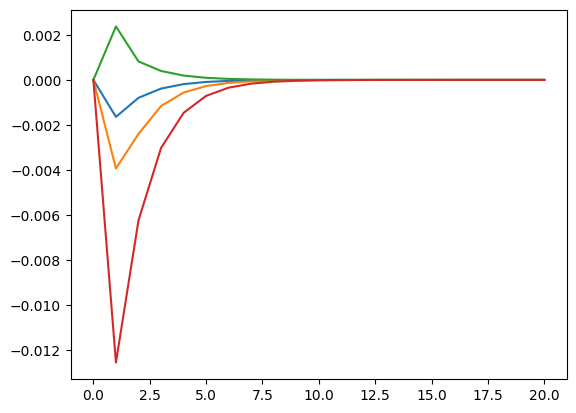

In [56]:
import matplotlib.pyplot as plt

plt.plot(k.T)
plt.plot(d.T)

In [ ]:
A = -A_1w
B = -A_0w
C = B_0w


S, T, _, _, Q, Z = ordqz(A, B, output='complex',sort=lambda alpha,beta: jnp.round(jnp.abs(beta/jnp.maximum(alpha,1e-15)),6)<=1) # type: ignore
Q = Q.conjugate().T
n_s = len([_ for i in range(S.shape[0]) if np.abs(S[i,i])>1e-6 and np.round(np.abs(T[i,i]/S[i,i]),6)<=1])

In [26]:
Theta_p = Z[n_s:,:n_s]@inv(Z[:n_s,:n_s])
Theta_x = Z[:n_s,:n_s]@inv(S[:n_s,:n_s])@T[:n_s,:n_s]@inv(Z[:n_s,:n_s])
M = -inv(T[n_s:,n_s:])@Q[n_s:,:]@C
N = (Z[n_s:,n_s:]-Z[n_s:,:n_s]@inv(Z[:n_s,:n_s])@Z[:n_s,n_s:])@M
L = Z[:n_s,:n_s]@inv(S[:n_s,:n_s])@((-T[:n_s,:n_s]@inv(Z[:n_s,:n_s])@Z[:n_s,n_s:]+T[:n_s,n_s:])@M+Q[:n_s,:]@C)
{'Theta_x':np.real(Theta_x),'Theta_p':np.real(Theta_p), 'N':np.real(N),'L':np.real(L)}

{'Theta_x': Array([[0.48428929]], dtype=float64),
 'Theta_p': Array([[ 1.46030814],
        [-0.49979227],
        [ 3.80077507]], dtype=float64),
 'N': Array([[-3.93324794e-01,  9.71445147e-17],
        [ 2.37217717e-01, -8.32667268e-17],
        [-1.25450002e+00,  1.00000000e+00]], dtype=float64),
 'L': Array([[-1.64165861e-01,  8.27103489e-17]], dtype=float64)}